In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
workDir = "C:/Users/mjrubino/OneDrive - State of North Carolina/PAD-US/"
gitDir = workDir + "PAD-US-DMS-Scoresheet-Analysis/"
dfCatchSumm = pd.read_csv(gitDir+"catchment_summary.csv")
dfCatchSumm.head(5)

,COMID,WQ_uplift_,WQ_Cotype,WQ_DIS_ID,WQ_Rank,WQ_Bin,Hab_uplift,Hab_COtype,Hab_DIS_ID,Hab_Rank,...,Hab_TRA_V,Hyd_TRA_V,Service_Area_Name,River_Basin_Name,Shape_Length,Shape_Area,Catchment_Area,PAD_Area,PAD_Perc,PAD_Count
0,12034381,47.040001,NaN,NaN,952.0,7.0,83.440002,NaN,NaN,720.0,...,NO,NO,Broad,Broad,28561.683929,1.897749e+07,1.258561e+07,0.0,0.0,0
1,12034539,91.779999,HH,03050105_44,74.0,1.0,188.720001,HH,03050105_34,12.0,...,YES,YES,Broad,Broad,10456.713220,3.456620e+06,2.297701e+06,0.0,0.0,0
2,12034835,44.689999,NaN,NaN,1019.0,8.0,76.029999,NaN,NaN,858.0,...,NO,NO,Broad,Broad,3297.580686,4.416971e+05,2.944960e+05,0.0,0.0,0
3,12035521,48.439999,NaN,NaN,919.0,7.0,89.480003,NaN,03050105_37,638.0,...,YES,YES,Broad,Broad,3741.490617,2.311275e+05,1.539001e+05,0.0,0.0,0
4,12036671,34.830002,NaN,NaN,1230.0,9.0,73.730003,NaN,NaN,904.0,...,NO,NO,Broad,Broad,7448.280335,1.652284e+06,1.095300e+06,0.0,0.0,0


In [3]:
dfCatchSumm.shape

(68982, 30)

In [4]:
# Summary stats for the full dataset of catchments with or without PAD 1&2 polygons
dfCatchSumm[['PAD_Area', 'PAD_Perc']].describe().apply(lambda x: x.apply('{:.3f}'.format))

,PAD_Area,PAD_Perc
count,68982.000,68982.000
mean,113715.194,5.117
std,1135769.890,19.082
min,0.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,0.000,0.000
max,118787847.579,100.000


In [5]:
# Get a subset of catchments that excludes those WITHOUT PAD polygons
dfPADonly = dfCatchSumm[dfCatchSumm['PAD_Perc']!=0]
dfPADonly.head(5)

,COMID,WQ_uplift_,WQ_Cotype,WQ_DIS_ID,WQ_Rank,WQ_Bin,Hab_uplift,Hab_COtype,Hab_DIS_ID,Hab_Rank,...,Hab_TRA_V,Hyd_TRA_V,Service_Area_Name,River_Basin_Name,Shape_Length,Shape_Area,Catchment_Area,PAD_Area,PAD_Perc,PAD_Count
25,12036765,56.070000,NaN,NaN,708.0,6.0,53.709999,NaN,NaN,1197.0,...,NO,NO,Broad,Broad,19217.748260,6.701283e+06,4.446002e+06,1.211542e+06,27.250000,2
31,12032721,72.919998,NaN,03050105_44,286.0,3.0,75.519997,NaN,NaN,867.0,...,NO,NO,Broad,Broad,16524.735361,8.438348e+06,5.574602e+06,1.178116e+06,21.129999,1
32,12034803,44.840000,NaN,NaN,1012.0,8.0,91.580002,NaN,NaN,609.0,...,NO,NO,Broad,Broad,15945.410960,6.243121e+06,4.161602e+06,1.971149e+05,4.740000,2
33,12032863,84.660004,HH,03050105_44,135.0,1.0,91.860001,NaN,NaN,601.0,...,NO,YES,Broad,Broad,16585.417492,7.848938e+06,5.188502e+06,2.905293e+05,5.600000,1
88,12034799,62.500000,NaN,NaN,533.0,4.0,68.900002,NaN,NaN,976.0,...,NO,NO,Broad,Broad,10653.190674,3.453766e+06,2.302201e+06,7.055899e+05,30.650000,2


In [6]:
dfPADonly.shape

(8952, 30)

In [7]:
# Summary stats for only catchments with PAD 1&2 polygons
dfPADonly[['PAD_Area', 'PAD_Perc']].describe().apply(lambda x: x.apply('{:.3f}'.format))

,PAD_Area,PAD_Perc
count,8952.000,8952.000
mean,876261.700,39.430
std,3045148.768,38.118
min,0.116,0.010
25%,30233.385,4.260
50%,179499.162,24.045
75%,760793.328,78.742
max,118787847.579,100.000


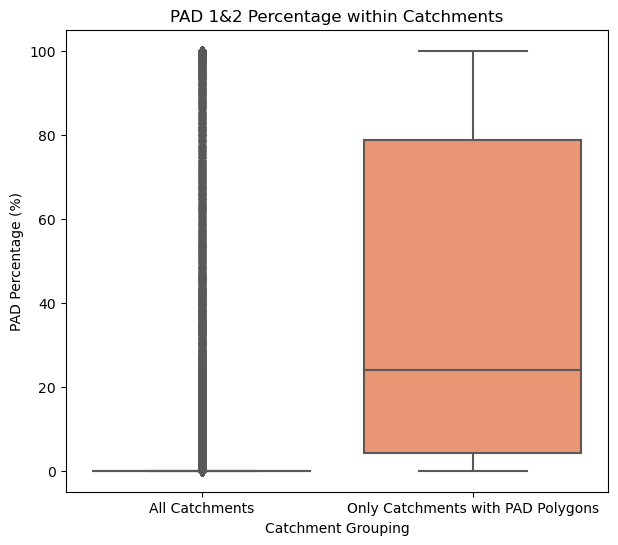

In [8]:
# Create a dataframe for all records
df_all = dfCatchSumm[['PAD_Perc']].copy()
df_all['Group'] = 'All Catchments'

# Create a dataframe for only non-zero records
df_non_zero = dfCatchSumm[dfCatchSumm['PAD_Perc'] != 0][['PAD_Perc']].copy()
df_non_zero['Group'] = 'Only Catchments with PAD Polygons'

# Concatenate the two dataframes
df_combined = pd.concat([df_all, df_non_zero])

# Create a single plot with both groups
plt.figure(figsize=(7, 6))
sns.boxplot(x='Group', y='PAD_Perc', data=df_combined, palette='Set2')

# Add labels and title
plt.title('PAD 1&2 Percentage within Catchments')
plt.ylabel('PAD Percentage (%)')
plt.xlabel('Catchment Grouping')

# Save the figure
plt.savefig('pad_perc_comparison.png')


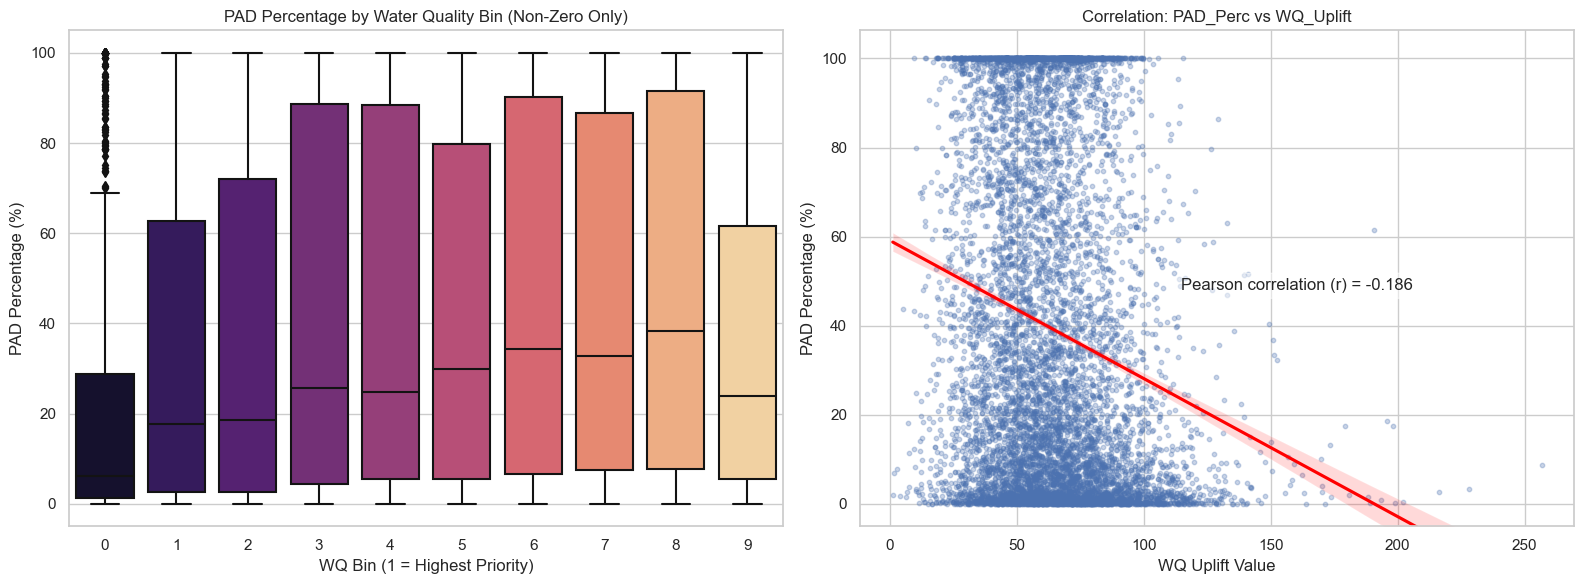

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load the dataset
df = pd.read_csv('catchment_summary.csv')

# Filter for records where PAD_Perc is not zero
df_filtered = df[df['PAD_Perc'] != 0].copy()

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PAD_Perc vs WQ_Bin (Categorized version of Rank/Uplift)
# This shows if higher priority bins have more/less protected land
sns.boxplot(x='WQ_Bin', y='PAD_Perc', data=df_filtered, ax=axes[0], palette='magma')
axes[0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
axes[0].set_title('PAD Percentage by Water Quality Bin (Non-Zero Only)')
axes[0].set_xlabel('WQ Bin (1 = Highest Priority)')
axes[0].set_ylabel('PAD Percentage (%)')

# Plot 2: Relationship check using a Scatter with a regression line
# Since Uplift is continuous, a scatter plot is often more insightful than a boxplot
# Calculate the correlation coefficient
correlation = df_filtered['PAD_Perc'].corr(df_filtered['WQ_uplift_'])

sns.regplot(x='WQ_uplift_', y='PAD_Perc', data=df_filtered, ax=axes[1], 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.text(0.45, 0.5, f'Pearson correlation (r) = {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.ylim(bottom=-5)
axes[1].set_title('Correlation: PAD_Perc vs WQ_Uplift')
axes[1].set_xlabel('WQ Uplift Value')
axes[1].set_ylabel('PAD Percentage (%)')

plt.tight_layout()
plt.show()

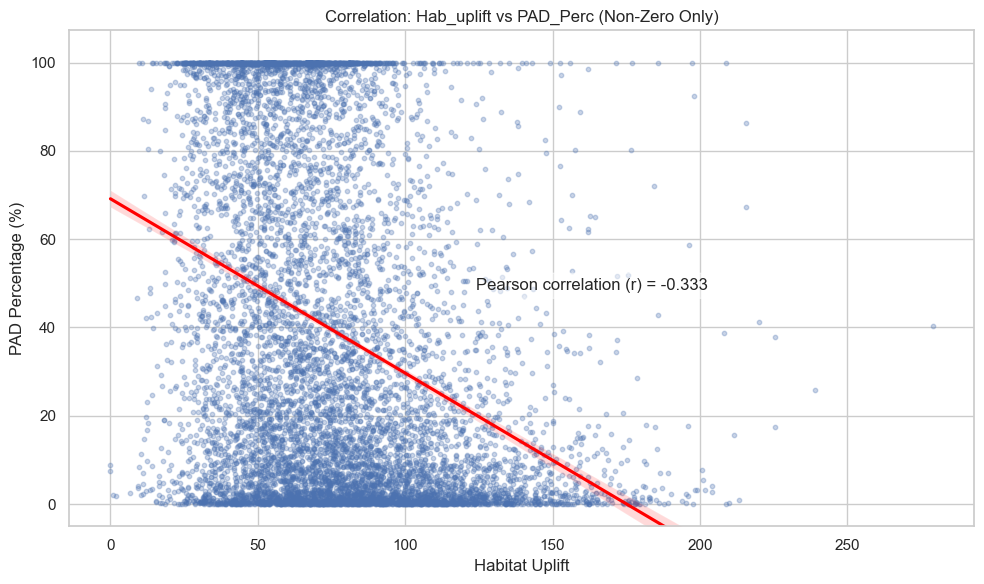

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('catchment_summary.csv')

# Filter for records where PAD_Perc is not zero
df_filtered = df[df['PAD_Perc'] != 0].copy()

# Calculate the correlation coefficient for the title
correlation = df_filtered['PAD_Perc'].corr(df_filtered['Hab_uplift'])

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Hab_uplift', y='PAD_Perc', data=df_filtered, 
            scatter_kws={'alpha':0.3, 's':10}, 
            line_kws={'color':'red'})
plt.ylim(bottom=-5)
# Add labels and title with the correlation value
plt.title(f'Correlation: Hab_uplift vs PAD_Perc (Non-Zero Only)')
plt.text(0.45, 0.5, f'Pearson correlation (r) = {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel('Habitat Uplift')
plt.ylabel('PAD Percentage (%)')

plt.tight_layout()
plt.savefig('hab_uplift_pad_perc_correlation.png')
plt.show()

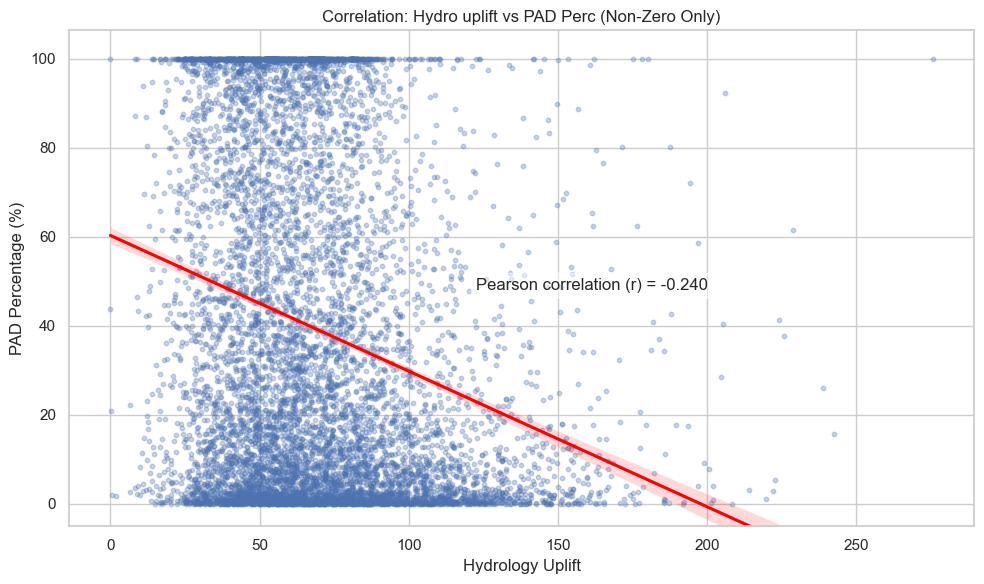

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('catchment_summary.csv')

# Filter for records where PAD_Perc is not zero
df_filtered = df[df['PAD_Perc'] != 0].copy()

# Calculate the correlation coefficient for the title
correlation = df_filtered['PAD_Perc'].corr(df_filtered['Hydro_upli'])

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Hydro_upli', y='PAD_Perc', data=df_filtered, 
            scatter_kws={'alpha':0.3, 's':10}, 
            line_kws={'color':'red'})
plt.ylim(bottom=-5)
# Add labels and title with the correlation value
plt.title(f'Correlation: Hydro uplift vs PAD Perc (Non-Zero Only)')
plt.text(0.45, 0.5, f'Pearson correlation (r) = {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.xlabel('Hydrology Uplift')
plt.ylabel('PAD Percentage (%)')

plt.tight_layout()
plt.show()